<a href="https://colab.research.google.com/github/PedroConst/EQE-358-Metodos-Numericos/blob/main/Lab/Gabarito_Lab_02_Coluna_Extra%C3%A7%C3%A3o_L%C3%ADquido_L%C3%ADquido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 02 – Coluna de Extração Líquido-Líquido**

## Objetivos
- Implementar matrizes esparsas, de banda e largas
- Resolver um sistema linear em Python usando Eliminação Gaussiana
- Avaliar as vantagens do Método de Decomposição LU

---

## Contexto
Link para vídeo: [Colunas de extração líquido-líquido](https://youtube.com/shorts/h8sbmkcz5sY?si=IffwzqnsO0CJg9bb)



Relação de equilíbrio termodinâmico:

$$
y_i=Kx_i
\tag{1}
$$

Balanços de massa em cada estágio da coluna:

$$
\begin{cases}
x_0F+y_2S=x_1F+y_1S,\ \ \ \ \ \  (i=1)
\\[6pt]
x_{i-1}F+y_{i+1}S=x_iF+y_iS,\ \ (2\le i\le n-1)
\\[6pt]
x_{n-1}F+y_0S=x_nF+y_nS,\ \ \ \ \  (i=n)
\end{cases}
\tag{2}
$$

##**🔹 Passo 1 – Importar bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

##**🔹 Passo 2 – Definir o Método LU**

In [ ]:
# Função que realiza a decomposição A = LU
def linear_LU(A):
    n = A.shape[0]
    U = np.zeros((n, n))
    L = np.eye(n)  # coloca 1 na diagonal

    for k in range(n - 1):
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k] = m  # armazena entrada para L
            for j in range(k + 1, n):
                A[i, j] = A[i, j] - m * A[k, j]

    for i in range(n):
        for j in range(i, n):
            U[i, j] = A[i, j]

    for i in range(1, n):
        for j in range(i):
            L[i, j] = A[i, j]

    return L, U

In [ ]:
# Função que resolve o sistema linear LUx=b
def linear_LU_forward_back(L, U, b):
    n = len(b)

    # Realiza a substituição direta (forward substitution)
    y = np.zeros(n)
    y[0] = b[0]
    for i in range(1, n):
        y[i] = b[i]
        for j in range(i):
            y[i] = y[i] - L[i, j] * y[j]

    # Realiza a substituição reversa (back substitution)
    x = np.zeros(n)
    x[n-1] = y[n-1] / U[n-1, n-1]
    for i in range(n-2, -1, -1):
        S = y[i]
        for j in range(i+1, n):
            S = S - U[i, j] * x[j]
        x[i] = S / U[i, i]

    return x

##**🔹 Passo 3 – Inserir Dados do Problema**

In [ ]:
n = 20      # Número de Estágios
S = 40.0    # Vazão do solvente (kg/h)
F = 65.0    # Vazão da alimentação (kg/h)
yo = 0.0    # Concentração inicial de soluto no solvente
K = 1.7     # Constante de Equilíbrio
xin = 0.25  # Concentração inicial de soluto na alimentação

##**🔹 Passo 4 – Alocar Variáveis**

In [ ]:
# Inicializar Matrizes e Vetores
A = np.zeros((n, n))
b = np.zeros(n)
x = np.zeros(n)

##**🔹 Passo 5 – Construir a matriz do sistema**

In [ ]:
# Montar o Sistema de Equações

# Primeiro Estágio
A[0, 0] = -(1 + S * K / F)
A[0, 1] = S * K / F
b[0] = -xin

# Estágios Interiores
for i in range(1,n-1):
    A[i, i - 1] = 1
    A[i, i] = -(1 + K * S / F)
    A[i, i + 1] = K * S / F

# Último Estágio
A[n-1, n - 2] = 1
A[n-1, n - 1] = -(1 + K * S / F)
b[n-1] = - S / F * yo

##**🔹 Passo 6 – Resolver o Sistema Linear**

In [ ]:
# Chamar a Função de Decomposição LU
# Eliminação (Forward) para obter L e U
L, U = linear_LU(A)

# Chamar a Função de Substituição (Forward) Ly = b
# Substituição (Backward) Ux = y
x = linear_LU_forward_back(L, U, b)

##**🔹 Passo 7 – Visualizar Resultados**

n 	 xi 		 yi
--------------------------------
0 	 0.2500 	 ------
1 	 0.2390 	 0.4063
2 	 0.2212 	 0.3761
3 	 0.2043 	 0.3473
4 	 0.1881 	 0.3197
5 	 0.1726 	 0.2934
6 	 0.1578 	 0.2682
7 	 0.1436 	 0.2442
8 	 0.1301 	 0.2212
9 	 0.1172 	 0.1992
10 	 0.1048 	 0.1782
11 	 0.0930 	 0.1581
12 	 0.0817 	 0.1389
13 	 0.0709 	 0.1205
14 	 0.0606 	 0.1030
15 	 0.0507 	 0.0862
16 	 0.0413 	 0.0702
17 	 0.0323 	 0.0548
18 	 0.0236 	 0.0402
19 	 0.0154 	 0.0262
20 	 0.0075 	 0.0128
--------------------------------


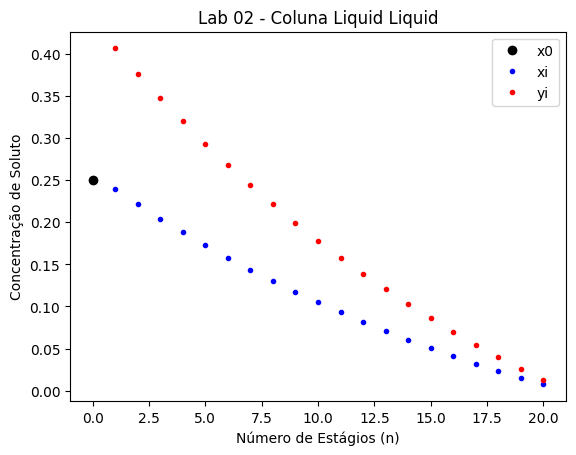

In [ ]:
# Imprimir Tabela
print('n \t xi \t\t yi')
print('--------------------------------')
print(f'0 \t {xin:.4f} \t ------')
for i in range(n):
    print(f'{i+1} \t {x[i]:.4f} \t {K*x[i]:.4f}')
print('--------------------------------')

# Plotar o Gráfico
nstage = np.arange(1,n+1,1)
plt.plot(0, xin, 'ok')
plt.plot(nstage,x,'.b')
plt.plot(nstage,K*x,'.r')
plt.legend(['x0', 'xi', 'yi'])
plt.xlabel('Número de Estágios (n)')
plt.ylabel('Concentração de Soluto')
plt.title('Lab 02 - Coluna Liquid Liquid')

plt.show()

##**🔹 Passo 8 – Definir Várias Concentrações**

In [ ]:
# Concentração inicial de soluto na alimentação
xin = np.arange(0.01,1,0.01)

##**🔹 Passo 9 – Alocar Variáveis**

In [ ]:
# Inicializar/Alocar variáveis
A = np.zeros((n, n))
b = np.zeros(n)

ntimes = len(xin)
x = np.zeros((n, ntimes)) # Definir x como uma matriz!

In [ ]:
# Montar o Sistema de Equações

# Primeiro Estágio
A[0, 0] = -(1 + S * K / F)
A[0, 1] = S * K / F

# Estágios Interiores
for i in range(1,n-1):
    A[i, i - 1] = 1
    A[i, i] = -(1 + K * S / F)
    A[i, i + 1] = K * S / F

# Útimo Estágio
A[n-1, n - 2] = 1
A[n-1, n - 1] = -(1 + K * S / F)
b[n-1] = -S / F * yo

In [ ]:
# Resolver por Decomposição LU
# Eliminação (Forward) para obter L e U
L, U = linear_LU(A)

# Fazer um loop para diferentes concentrações iniciais
for k in range(0,ntimes):
    b[0] = -xin[k]
    x[:,k] = linear_LU_forward_back(L, U, b)

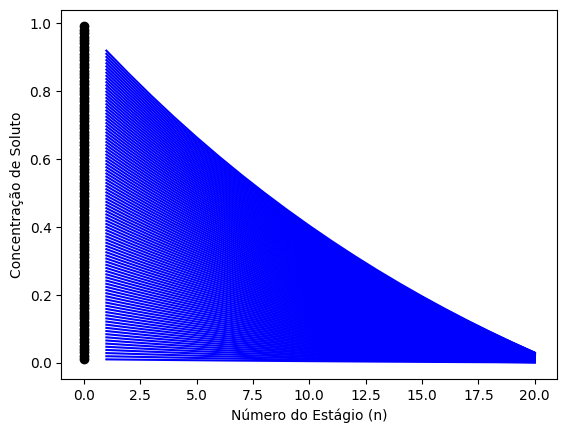

In [ ]:
# Plotar o Gráfico
nstage = np.arange(1,n+1,1)
for k in range(0,ntimes):
    plt.plot(0, xin[k], 'ok')
    plt.plot(nstage, x[:, k], 'b')
plt.xlabel('Número do Estágio (n)')
plt.ylabel('Concentração de Soluto')
plt.show()